In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os
zip_path = '/content/drive/MyDrive/icecream dataset.zip'
extract_path = '/content/icecream_dataset'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
print("✅ Dataset extracted!")

✅ Dataset extracted!


In [ ]:
# STEP 3: Define paths
# ==============================
train_dir = os.path.join(extract_path, 'train')
val_dir = os.path.join(extract_path, 'valid')
test_dir = os.path.join(extract_path, 'test')
# STEP 3: Define paths
# ==============================
train_dir = os.path.join(extract_path, 'dataset', 'train')
val_dir = os.path.join(extract_path, 'dataset', 'valid')
test_dir = os.path.join(extract_path, 'dataset', 'test')

In [ ]:
# STEP 4: Load images with ImageDataGenerator
# ==============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)


In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 718 images belonging to 2 classes.


In [ ]:
# Check the contents of the extracted directory
extracted_contents = os.listdir(extract_path)
print("Contents of extracted directory:")
print(extracted_contents)

# Check if train_dir exists
if os.path.exists(train_dir):
    print(f"'{train_dir}' exists.")
else:
    print(f"'{train_dir}' does not exist.")

Contents of extracted directory:
['dataset', 'README.md']
'/content/icecream_dataset/dataset/train' exists.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 106 images belonging to 2 classes.


In [ ]:
# STEP 5: Build a CNN model
# ==============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_generator.num_classes, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 5, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,682 (1.31 MB)

 Trainable params: 343,682 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 208 images belonging to 2 classes.


In [ ]:
# STEP 6: Compile and Train
# ==============================
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)


Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5152 - loss: 0.6889

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5175 - loss: 0.6885 - val_accuracy: 0.8413 - val_loss: 0.6438
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8040 - loss: 0.6099 - val_accuracy: 0.8317 - val_loss: 0.4594
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8016 - loss: 0.4775 - val_accuracy: 0.8269 - val_loss: 0.3776
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.8045 - loss: 0.4166 - val_accuracy: 0.8606 - val_loss: 0.3363
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8374 - loss: 0.3677 - val_accuracy: 0.8894 - val_loss: 0.3015
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8211 - loss: 0.4046 - val_accuracy: 0.8990 - val_loss: 0.2831
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8600 - loss: 0.3365 - val_accuracy: 0.9038 - val_loss: 0.2907
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8539 - loss: 0.3721 - val_accuracy: 0.8413 - val_loss: 0.3452
Epo

In [ ]:
# STEP 7: Evaluate on Test Set
# ==============================
test_loss, test_acc = model.evaluate(test_generator)
print(f"✅ Test Accuracy: {test_acc:.2f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.8593 - loss: 0.3473
✅ Test Accuracy: 0.88


In [ ]:
# STEP 8: Save the Model
# ==============================
model.save('/content/icecream_cnn_model.h5')
print("💾 Model saved successfully!")


💾 Model saved successfully!


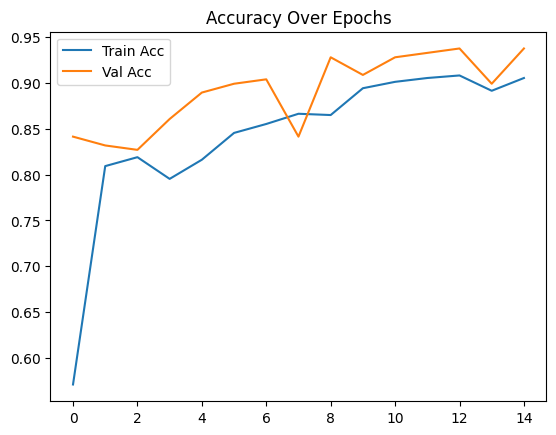

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.show()



In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 106 images belonging to 2 classes.


In [ ]:
import numpy as np

# Get predictions
predictions = model.predict(test_generator)

# Convert probabilities → class index
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# View example results
print("✅ Class labels:", class_labels)
print("🔹 Predicted:", predicted_classes[:10])
print("🔹 True:", true_classes[:10])


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step
✅ Class labels: ['icecream', 'pizza']
🔹 Predicted: [0 0 0 1 0 0 1 0 0 0]
🔹 True: [0 0 0 0 0 0 0 0 0 0]


              precision    recall  f1-score   support

    icecream       0.94      0.83      0.88        59
       pizza       0.81      0.94      0.87        47

    accuracy                           0.88       106
   macro avg       0.88      0.88      0.88       106
weighted avg       0.89      0.88      0.88       106



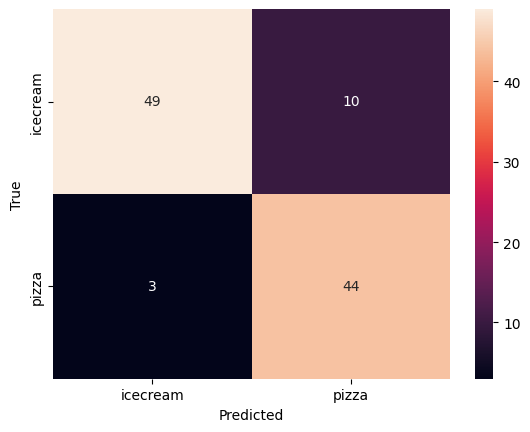

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Example path (change this)
img_path = '/content/icecream_dataset/dataset/test/pizza/00160_jpg.rf.6d20386d86171b64656551201465521f.jpg'

# Load and preprocess image
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension
img_array = img_array / 255.0  # same scaling used in training

# Predict
prediction = model.predict(img_array)
predicted_class_index = np.argmax(prediction, axis=1)[0]
predicted_label = class_labels[predicted_class_index]

print(f"🍦 Predicted class: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
🍦 Predicted class: pizza


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Example path (change this)
img_path = '/content/icecream_dataset/dataset/test/icecream/00190_jpg.rf.9f24ad985e14ceebd07dfe8799a4c01e.jpg'

# Load and preprocess image
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension
img_array = img_array / 255.0  # same scaling used in training

# Predict
prediction = model.predict(img_array)
predicted_class_index = np.argmax(prediction, axis=1)[0]
predicted_label = class_labels[predicted_class_index]

print(f"🍦 Predicted class: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
🍦 Predicted class: icecream


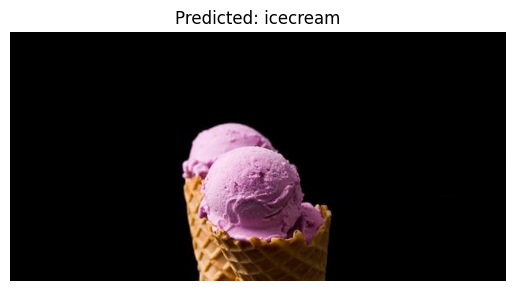

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()
